In [ ]:
!wget -O names.txt https://raw.githubusercontent.com/karpathy/makemore/master/names.txt

--2026-08-20 09:07:56--  https://raw.githubusercontent.com/karpathy/makemore/master/names.txt
Resolving raw.githubusercontent.com (raw.githubusercontent.com)... 185.199.108.133, 185.199.109.133, 185.199.110.133, ...
Connecting to raw.githubusercontent.com (raw.githubusercontent.com)|185.199.108.133|:443... connected.
HTTP request sent, awaiting response... 200 OK
Length: 228145 (223K) [text/plain]
Saving to: ‘names.txt’

names.txt           100%[===================>] 222.80K  --.-KB/s    in 0.02s   

2026-08-20 09:07:56 (14.3 MB/s) - ‘names.txt’ saved [228145/228145]



In [ ]:
words = open("names.txt", "r").read().splitlines()
words[:8]

['emma', 'olivia', 'ava', 'isabella', 'sophia', 'charlotte', 'mia', 'amelia']

In [ ]:
import torch
import torch.nn.functional as F
import matplotlib.pyplot as plt
%matplotlib inline

In [ ]:
chars = sorted(list(set(''.join(words))))
stoi = {s:i+1 for i,s in enumerate(chars)}
stoi['.'] = 0
itos = {i:s for s, i in stoi.items()}
vocab_size = len(itos)
print(itos)
print(vocab_size)

{1: 'a', 2: 'b', 3: 'c', 4: 'd', 5: 'e', 6: 'f', 7: 'g', 8: 'h', 9: 'i', 10: 'j', 11: 'k', 12: 'l', 13: 'm', 14: 'n', 15: 'o', 16: 'p', 17: 'q', 18: 'r', 19: 's', 20: 't', 21: 'u', 22: 'v', 23: 'w', 24: 'x', 25: 'y', 26: 'z', 0: '.'}
27


In [ ]:
block_size = 8
def build_dataset(words):
  X, Y = [], []
  # ...arman .
  for w in words:
    # print(w)
    context = [0]*block_size
    for ch in w+'.':
      ix = stoi[ch]
      X.append(context)
      Y.append(ix)
      # print(''.join(itos[i] for i in context), '--->', itos[ix])
      context = context[1:]+[ix]

  X = torch.tensor(X)
  Y = torch.tensor(Y)
  print(X.shape,Y.shape)
  return X,Y

import random
random.seed(42)
random.shuffle(words)
n1 = int(0.8*len(words))
n2 = int(0.9*len(words))

Xtr, Ytr = build_dataset(words[:n1]) # training set 80 %
Xdev, Ydev = build_dataset(words[n1:n2]) # dev set 10 %
Xte, Yte = build_dataset(words[n2:]) # testing set 10 %

torch.Size([182437, 8]) torch.Size([182437])
torch.Size([22781, 8]) torch.Size([22781])
torch.Size([22928, 8]) torch.Size([22928])


In [ ]:
# n_embed = 10
# n_hidden = 200
# # Everyhting all together
# g = torch.Generator().manual_seed(2147483647)
# C = torch.randn((vocab_size, n_embed), generator = g) # [27,10]
# W1 = torch.randn((n_embed*block_size, n_hidden), generator = g) * (5/3)/((n_embed*block_size)**0.5)  # [30,200]
# b1 = torch.randn(n_hidden, generator = g) *.01 # [200]
# W2 = torch.randn((n_hidden, vocab_size), generator = g) * 0.01 # [200,27]
# b2 = torch.randn(vocab_size, generator = g) * 0 # [27]

# bngain = torch.ones((1,n_hidden)) # [1,200]
# bnbias = torch.zeros((1,n_hidden)) # [1,200]
# bnmean_running = torch.zeros((1,n_hidden)) # [1,200]
# bnstd_running = torch.ones((1,n_hidden)) # [1,200]

# parameters = [C, W1, b1, W2, b2]
# for p in parameters:
#   p.requires_grad = True
# sum(p.nelement() for p in parameters)

In [ ]:
# Let's train a deeper network
# The classes we create here are the same API as nn.Module in PyTorch

class Linear:
  def __init__(self, fan_in, fan_out, bias=True):
    self.weight = torch.randn((fan_in, fan_out)) / fan_in**0.5
    self.bias = torch.zeros(fan_out) if bias else None

  # this is to replace L1 = Linear(fi,fo) ; L1.multiply(x) { but now we can directly write this as L1(x)}
  def __call__(self, x):
    self.out = x @ self.weight
    if self.bias is not None:
      self.out += self.bias
    return self.out

  def parameters(self):
    return [self.weight] + ([] if self.bias is None else [self.bias])

class BatchNorm1d:
  def __init__(self, dim, eps=1e-5, momentum=0.1):
    self.eps = eps
    self.momentum = momentum
    self.training = True
    # parameters (trained with backprop)
    self.gamma = torch.ones(dim)
    self.beta = torch.zeros(dim)
    # buffers (trained with a running 'momentum update')
    self.running_mean = torch.zeros(dim)
    self.running_var = torch.ones(dim)

  def __call__(self, x):
    # calculate the forward pass
    if self.training:
      if x.ndim == 2:
        dim = 0
      elif x.ndim == 3:
        dim = (0,1)
      xmean = x.mean(dim, keepdim=True) # batch mean
      xvar = x.var(dim, keepdim=True) # batch variance
    else:
      xmean = self.running_mean
      xvar = self.running_var
    xhat = (x - xmean) / torch.sqrt(xvar + self.eps) # normalize to unit variance (as per that Google @2015 paper)
    self.out = self.gamma * xhat + self.beta
    # update the buffers
    if self.training:
      with torch.no_grad():
        self.running_mean = (1 - self.momentum) * self.running_mean + self.momentum * xmean
        self.running_var = (1 - self.momentum) * self.running_var + self.momentum * xvar
    return self.out

  def parameters(self):
    return [self.gamma, self.beta]


class Tanh:
  def __call__(self, x):
    self.out = torch.tanh(x)
    return self.out

  def parameters(self):
    return []

class Embedding:
  def __init__(self, num_embeddings, embedding_dim):
    self.weight = torch.randn((num_embeddings, embedding_dim))

  def __call__(self,IX):
    self.out = self.weight[IX]
    return self.out

  def parameters(self):
    return [self.weight]

class FlattenConsecutive:
  def __init__(self,n):
    self.n = n

  def __call__(self,x):
    """
    B, T, C = x.shape
    B = Batch size (# examples)
    T = Time/sequence steps (# characters)
    fC = Channels/features per step (embedding dimension)
    """

    B, T, C = x.shape
    x = x.view(B, T//self.n, C*self.n)
    if x.shape[1] == 1:
      x= x.squeeze(1)
    self.out = x
    return self.out

  def parameters(self):
    return []

class Sequential:

  def __init__(self, layers):
    self.layers = layers

  def __call__(self, x):
    for layer in self.layers:
      x = layer(x)
    self.out = x
    return self.out

  def parameters(self):
    return [p for layer in self.layers for p in layer.parameters()]

n_embed = 10 # the dimensionality of the character embedding vectors
n_hidden = 200 # the number of neurons in the hidden layer of the MLP
g = torch.Generator().manual_seed(2147483647)
# C = torch.randn((vocab_size,n_embed), generator=g)
# we can remove this Tanh(), but that will leads to a calculated behaviour i.e. linear i/p and o/p; the the activation function help it somewhat so we can teach a
# nerual network to work on arbitary data, given we trained it. idk its jittey but for now bear this
model = Sequential([
    Embedding(vocab_size, n_embed),
    FlattenConsecutive(2), Linear(n_embed*2,n_hidden, bias = False), BatchNorm1d(n_hidden), Tanh(),
    FlattenConsecutive(2), Linear(n_hidden*2,n_hidden, bias = False), BatchNorm1d(n_hidden), Tanh(),
    FlattenConsecutive(2), Linear(n_hidden*2,n_hidden, bias = False), BatchNorm1d(n_hidden), Tanh(),
    Linear(n_hidden, vocab_size),
])



"""
this above MLP have following

Input(30)->Layer1(100)->Tanh()->Layer2(100)->Tanh()->Layer3(100)->Tanh()->Layer4(100)->Tanh()->Layer5(100)->Tanh()->Layer6(27)

Input is 30 coz n_embed = 10 and block_size = 3 i.e. [e,m,m] -> [0.1,0.4,45,.....5.6] this single example will have 30 data point

now let say output is [e,m,m] -> [a] i.e. we can have 27 possible characters thus output as 27 (we have 0 -> '.')

"""


with torch.no_grad():
  # last layer: make less confident coz we dont want that it randomly assign high confidence an character which is not supposed to be (i.e. learning will have to make a lot of effort to correct itself)
  # conclusion: we can have smooth start in training
  model.layers[-1].weight *= 0.1

  # all other layers: apply gain (as Tanh() try to squash them overtime, i.e. std will come near to 0, so mathmatically calculated gain is multiplied)
  for layer in model.layers[:-1]:
    if isinstance(layer, Linear):
      layer.weight *=  5/3

parameters = model.parameters()
print(sum(p.nelement() for p in parameters))
for p in parameters:
  p.requires_grad = True


170897


In [ ]:
Xtr.shape, Xtr.shape[0]

(torch.Size([182437, 8]), 182437)

In [ ]:
#  same optimization as last time
max_steps = 200000
batch_size = 32
lossi = []
# update to data ratio
# ud = []

for i in range(max_steps):

  # minibatch construct
  ix = torch.randint(0, Xtr.shape[0], (batch_size,), generator=g)
  Xb, Yb = Xtr[ix], Ytr[ix] # batch X,Y

  # forward pass
  # emb = C[Xb] # embed the characters into vectors
  # x = emb.view(emb.shape[0], -1) # concatenate the vectors
  # x = Xb
  # for layer in layers:
  #   x = layer(x)
  logits = model(Xb)
  loss = F.cross_entropy(logits, Yb) # loss function

  for p in parameters:
    p.grad = None
  loss.backward()

  # update
  lr = 0.1 if i < 150000 else 0.01 # step learning rate decay
  for p in parameters:
    p.data += -lr * p.grad

  # track stats
  if i % 10000 == 0: # print every once in a while
    print(f'{i:7d}/{max_steps:7d}: {loss.item():.4f}')
  lossi.append(loss.log10().item())

  # if i >= 10000:
  #   break # AFTER_DEBUG: would take out obviously to run full optimization

      0/ 200000: 3.3068
  10000/ 200000: 2.3409
  20000/ 200000: 1.9142
  30000/ 200000: 1.9723
  40000/ 200000: 2.1809
  50000/ 200000: 2.0071
  60000/ 200000: 1.9760
  70000/ 200000: 2.0895
  80000/ 200000: 1.7848
  90000/ 200000: 1.8791
 100000/ 200000: 1.9948
 110000/ 200000: 2.0081
 120000/ 200000: 1.9691
 130000/ 200000: 1.8692
 140000/ 200000: 1.6383
 150000/ 200000: 1.7748
 160000/ 200000: 1.4291
 170000/ 200000: 1.9462
 180000/ 200000: 2.1286
 190000/ 200000: 1.8977


In [ ]:
for layer in model.layers:
  print(layer.__class__.__name__, ':', tuple(layer.out.shape))

Embedding : (32, 8, 10)
FlattenConsecutive : (32, 4, 20)
Linear : (32, 4, 200)
BatchNorm1d : (32, 4, 200)
Tanh : (32, 4, 200)
FlattenConsecutive : (32, 2, 400)
Linear : (32, 2, 200)
BatchNorm1d : (32, 2, 200)
Tanh : (32, 2, 200)
FlattenConsecutive : (32, 400)
Linear : (32, 200)
BatchNorm1d : (32, 200)
Tanh : (32, 200)
Linear : (32, 27)


In [ ]:
for layer in model.layers:
    if isinstance(layer, FlattenConsecutive):
        print("Flatten n =", layer.n)

Flatten n = 2
Flatten n = 2
Flatten n = 2


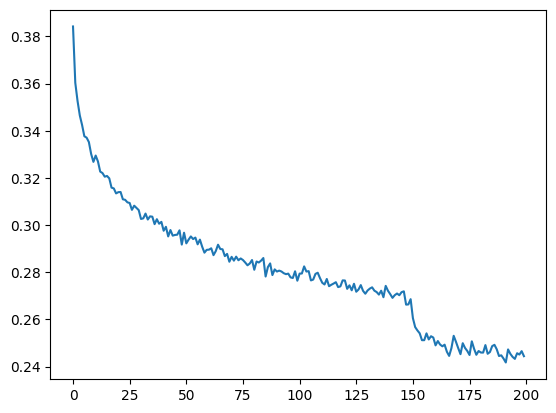

In [ ]:
 plt.plot(torch.tensor(lossi).view(-1,1000).mean(1))

In [ ]:
@torch.no_grad()
def split_loss(split):
    x, y = {
        'train': (Xtr, Ytr),
        'val': (Xdev, Ydev),
        'test': (Xte, Yte),
    }[split]
    logits = model(x)
    loss = F.cross_entropy(logits, y)
    print(split, loss.item())

split_loss('train')
split_loss('val')


train 1.7344719171524048
val 1.9970594644546509


In [ ]:
# sample from the model

g = torch.Generator().manual_seed(2147483647)

# Put BatchNorm layers in inference mode
for layer in model.layers:
    if isinstance(layer, BatchNorm1d):
        layer.training = False

for _ in range(20):

    out = []
    context = [0] * block_size  # initialize with all ...

    while True:
        # character IDs → embeddings
        # emb = C[torch.tensor([context])]
        # # concatenate embeddings
        # x = emb.view(1, -1)
        # # pass through the SAME network we trained
        # for layer in layers:
        #     x = layer(x)
        # # x is now the logits
        # logits = x
        logits = model(torch.tensor([context]))
        # logits → probabilities
        probs = F.softmax(logits, dim=1)
        # ix = probs.argmax().item()
        # sample next character
        ix = torch.multinomial(
            probs,
            num_samples=1,
            generator=g
        ).item()
        # move context window forward
        context = context[1:] + [ix]
        # save generated character
        out.append(ix)
        # 0 = '.'
        if ix == 0:
            break
    print(''.join(itos[i] for i in out))

cexim.
moulynn.
ilah.
tyharr.
jimi.
nain.
lucyn.
katar.
samiyah.
javari.
mari.
moriella.
kinzlee.
artavio.
masideu.
niavi.
nyra.
brexli.
jennata.
lava.


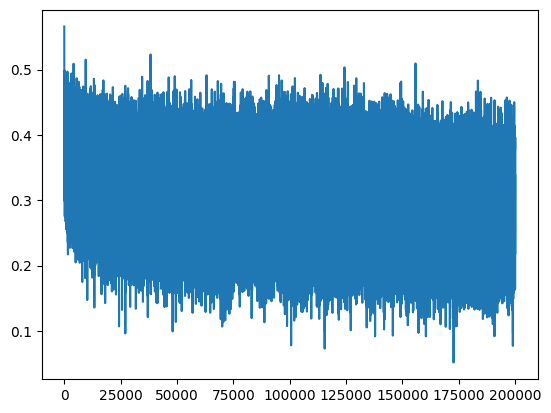

In [ ]:
plt.plot(lossi)

layer 4 (      Tanh): mean +0.07, std 0.83, saturated: 37.00%


/tmp/ipykernel_921/2542595642.py:8: UserWarning: Converting a tensor with requires_grad=True to a scalar may lead to unexpected behavior.
Consider using tensor.detach() first. (Triggered internally at /pytorch/torch/csrc/autograd/generated/python_variable_methods.cpp:836.)
  print('layer %d (%10s): mean %+.2f, std %.2f, saturated: %.2f%%' % (i, layer.__class__.__name__, t.mean(), t.std(), (t.abs() > 0.97).float().mean()*100))


Text(0.5, 1.0, 'activation distribution')

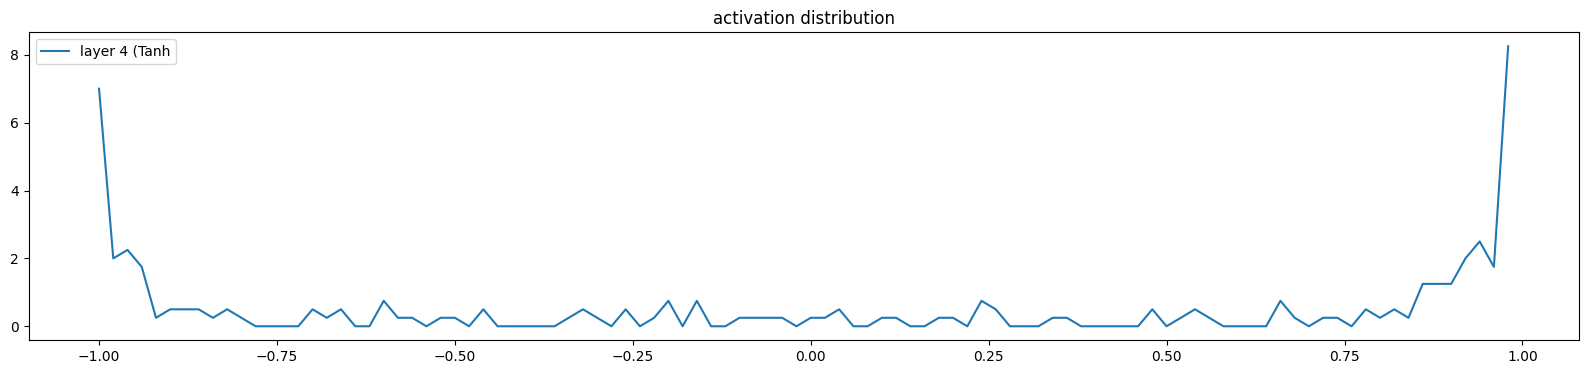

In [ ]:
# visualize forward pass histograms  ( this one help us to see in the inner tanh layers wheather they are saturated(dead) or non-saturated, high saturation will kill the neurons as there will be
# no change in weight/biases during backpropogation; so through this tool we aim to fix the saturation of out network)
plt.figure(figsize=(20, 4)) # width and height of the plot
legends = []
for i, layer in enumerate(model.layers[:-1]): # note: exclude the output layer
  if isinstance(layer, Tanh):
    t = layer.out
    print('layer %d (%10s): mean %+.2f, std %.2f, saturated: %.2f%%' % (i, layer.__class__.__name__, t.mean(), t.std(), (t.abs() > 0.97).float().mean()*100))
    hy, hx = torch.histogram(t, density=True)
    plt.plot(hx[:-1].detach(), hy.detach())
    legends.append(f'layer {i} ({layer.__class__.__name__}')
plt.legend(legends);
plt.title('activation distribution')

In [ ]:
# visualize backword pass histograms (this one help us to figure out that our gradients are travelling roughly at same pattern thorought out the layers, as diffrent setting may lead to die out
# of these gradient / or explode it)
plt.figure(figsize=(20, 4)) # width and height of the plot
legends = []
for i, layer in enumerate(model.layers[:-1]): # note: exclude the output layer
  if isinstance(layer, Tanh):
    t = layer.out.grad
    print('layer %d (%10s): mean %+f, std %e' % (i, layer.__class__.__name__, t.mean(), t.std()))
    hy, hx = torch.histogram(t, density=True)
    plt.plot(hx[:-1].detach(), hy.detach())
    legends.append(f'layer {i} ({layer.__class__.__name__}')
plt.legend(legends);
plt.title('gradient distribution')

/tmp/ipykernel_921/1596328957.py:7: UserWarning: The .grad attribute of a Tensor that is not a leaf Tensor is being accessed. Its .grad attribute won't be populated during autograd.backward(). If you indeed want the .grad field to be populated for a non-leaf Tensor, use .retain_grad() on the non-leaf Tensor. If you access the non-leaf Tensor by mistake, make sure you access the leaf Tensor instead. See github.com/pytorch/pytorch/pull/30531 for more information. (Triggered internally at /pytorch/build/aten/src/ATen/core/TensorBody.h:494.)
  t = layer.out.grad


AttributeError: 'NoneType' object has no attribute 'mean'

<Figure size 2000x400 with 0 Axes>

weight   (27, 10) | mean -0.000000 | std 1.382795e-02 | grad:data ratio 1.322595e-02
weight  (30, 100) | mean +0.000013 | std 8.717334e-03 | grad:data ratio 2.413300e-02
weight (100, 100) | mean -0.000006 | std 5.755450e-03 | grad:data ratio 2.701870e-02
weight (100, 100) | mean -0.000115 | std 5.910460e-03 | grad:data ratio 2.785145e-02
weight (100, 100) | mean +0.000069 | std 5.563086e-03 | grad:data ratio 2.627925e-02
weight (100, 100) | mean +0.000025 | std 5.327831e-03 | grad:data ratio 2.526486e-02
weight  (100, 27) | mean +0.000000 | std 1.812772e-02 | grad:data ratio 9.575676e-02


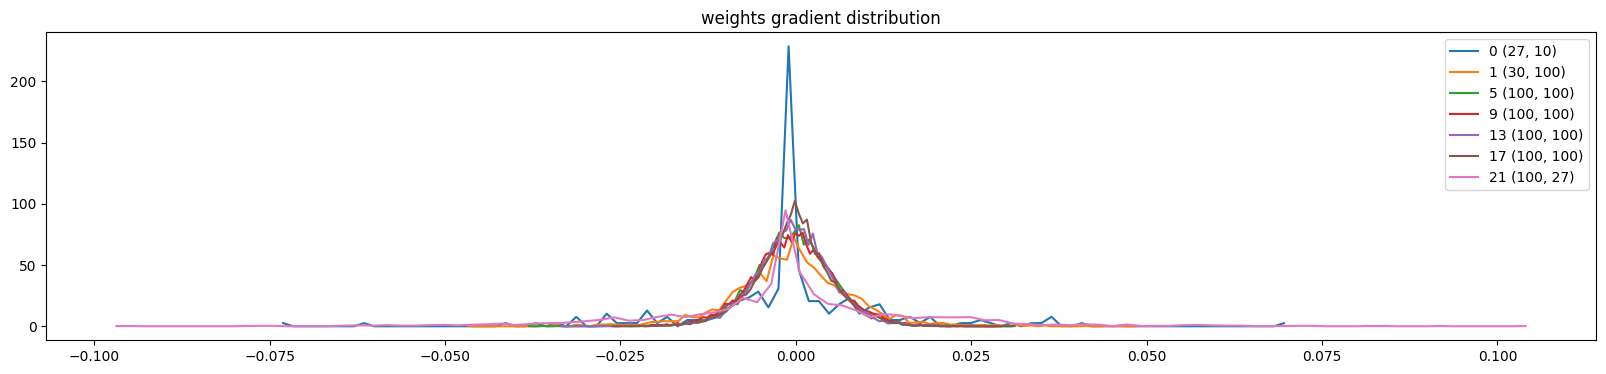

In [ ]:
# visualize histograms (# this can usefull for observing the learning rate [how much we are adjusting the weights, we have to figure out best learning rate )
plt.figure(figsize=(20, 4)) # width and height of the plot
legends = []
for i,p in enumerate(parameters):
  t = p.grad
  if p.ndim == 2:
    print('weight %10s | mean %+f | std %e | grad:data ratio %e' % (tuple(p.shape), t.mean(), t.std(), t.std() / p.std()))
    hy, hx = torch.histogram(t, density=True)
    plt.plot(hx[:-1].detach(), hy.detach())
    legends.append(f'{i} {tuple(p.shape)}')
plt.legend(legends)
plt.title('weights gradient distribution');

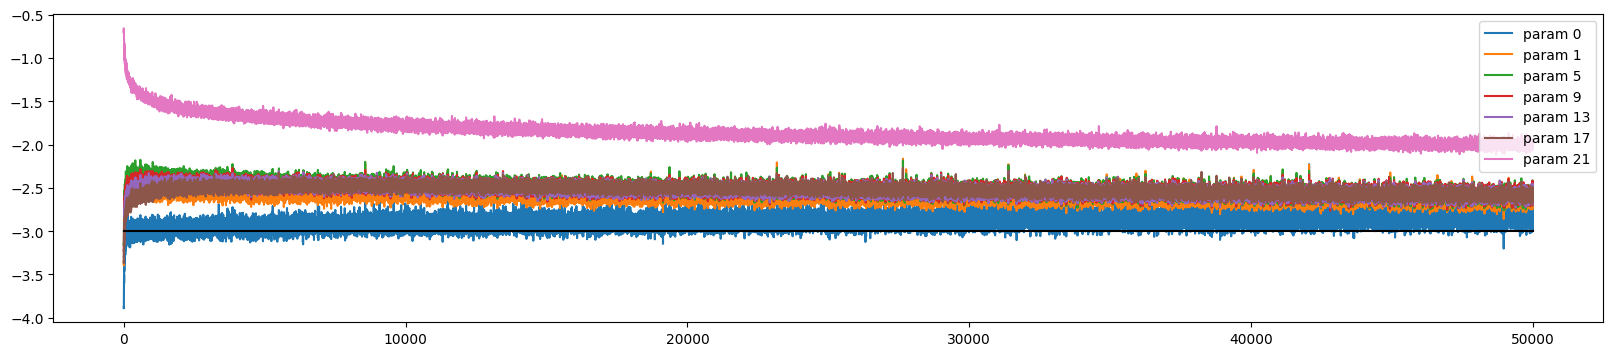

In [ ]:
# this can usefull for observing the learning rate [how much we are adjusting the weights, we have to figure out best learning rate )
plt.figure(figsize=(20, 4))
legends = []
for i,p in enumerate(parameters):
  if p.ndim == 2:
    plt.plot([ud[j][i] for j in range(len(ud))])
    legends.append('param %d' % i)
plt.plot([0, len(ud)], [-3, -3], 'k') # these ratios should be ~1e-3, indicate on plot
plt.legend(legends);


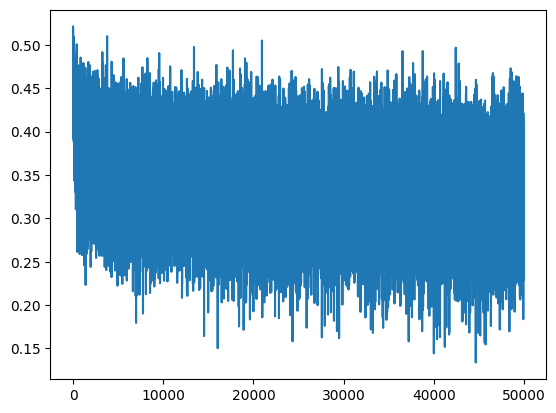

In [ ]:
plt.plot(lossi)

layer 2: shape=(200, 100), saturated=4.22%


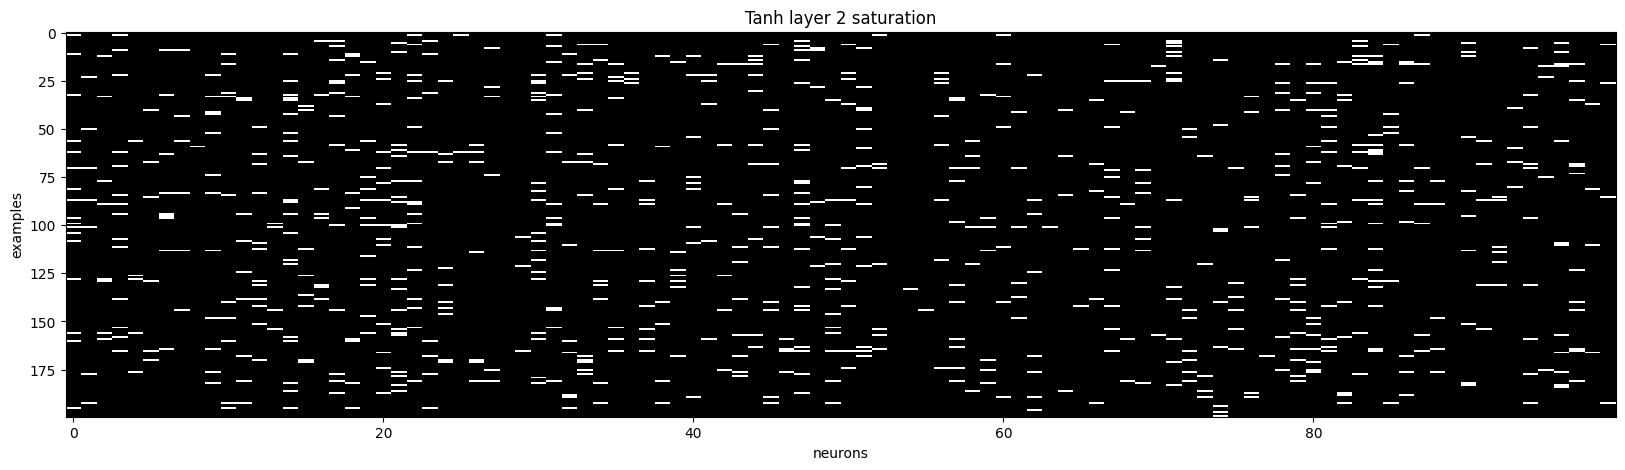

layer 5: shape=(200, 100), saturated=4.88%


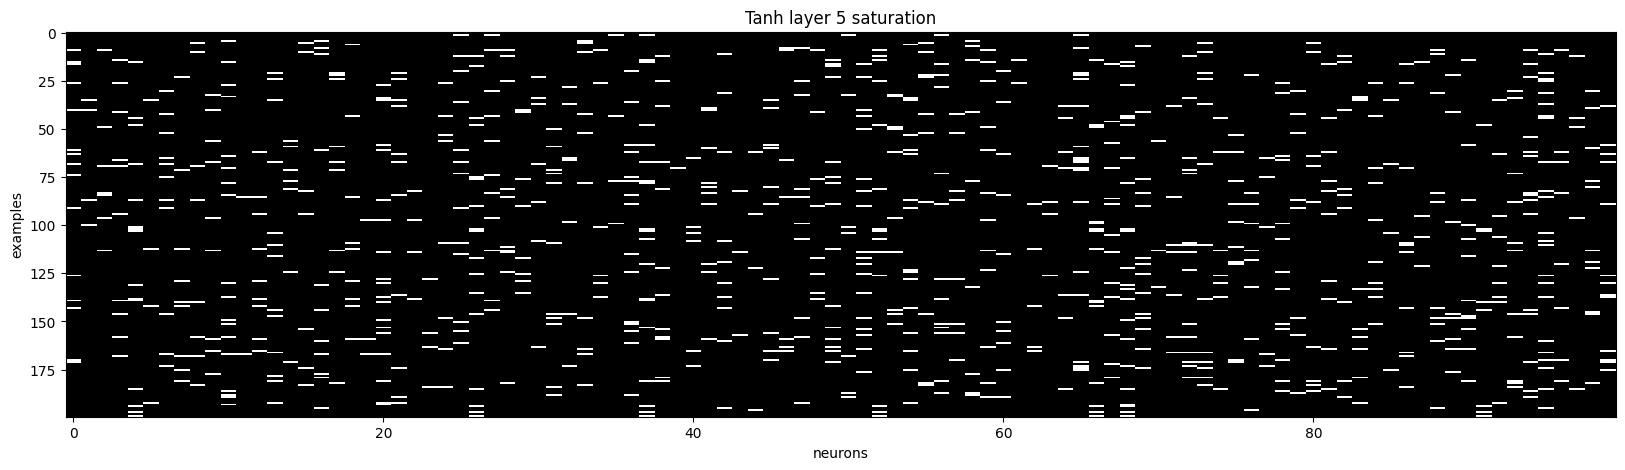

layer 8: shape=(200, 100), saturated=4.66%


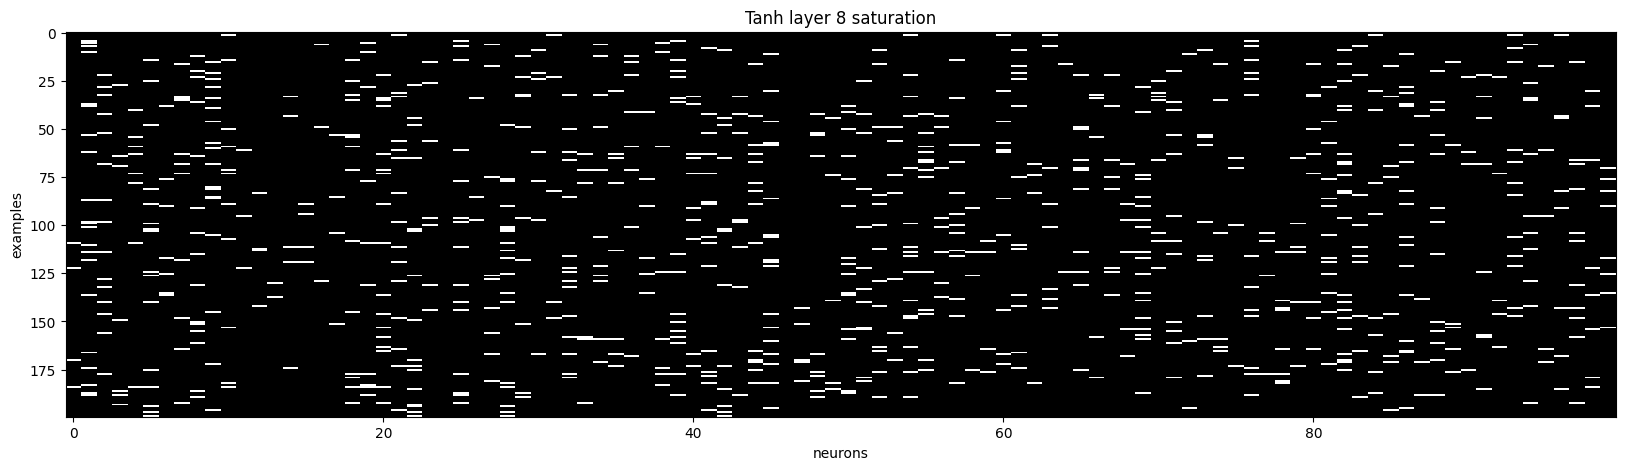

layer 11: shape=(200, 100), saturated=4.05%


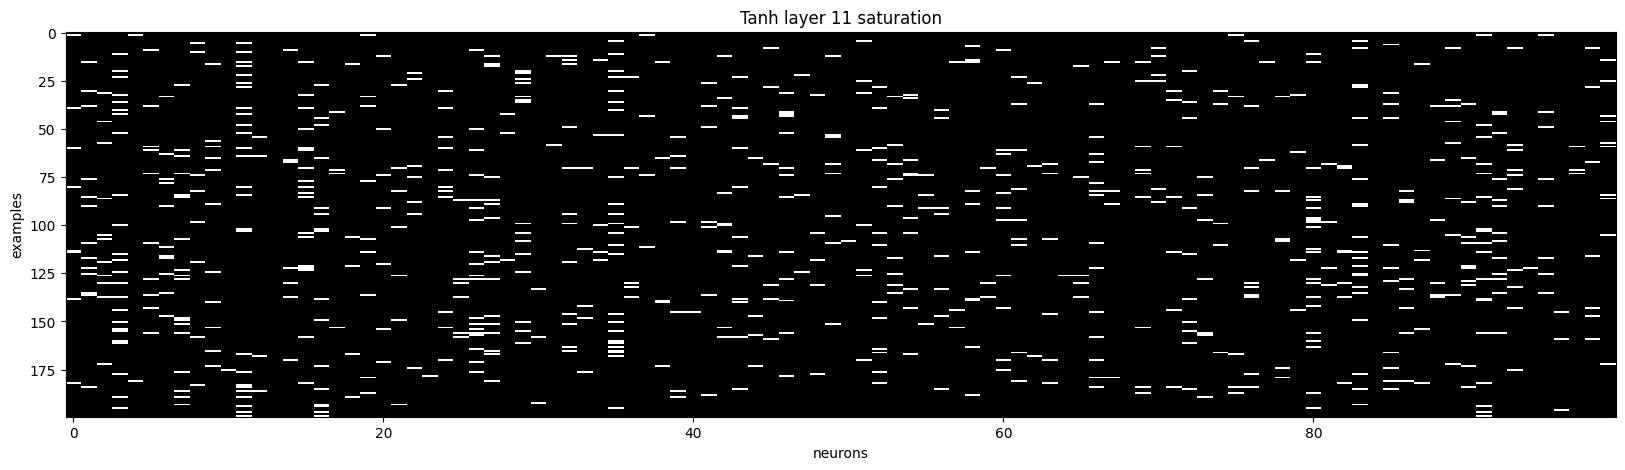

layer 14: shape=(200, 100), saturated=1.47%


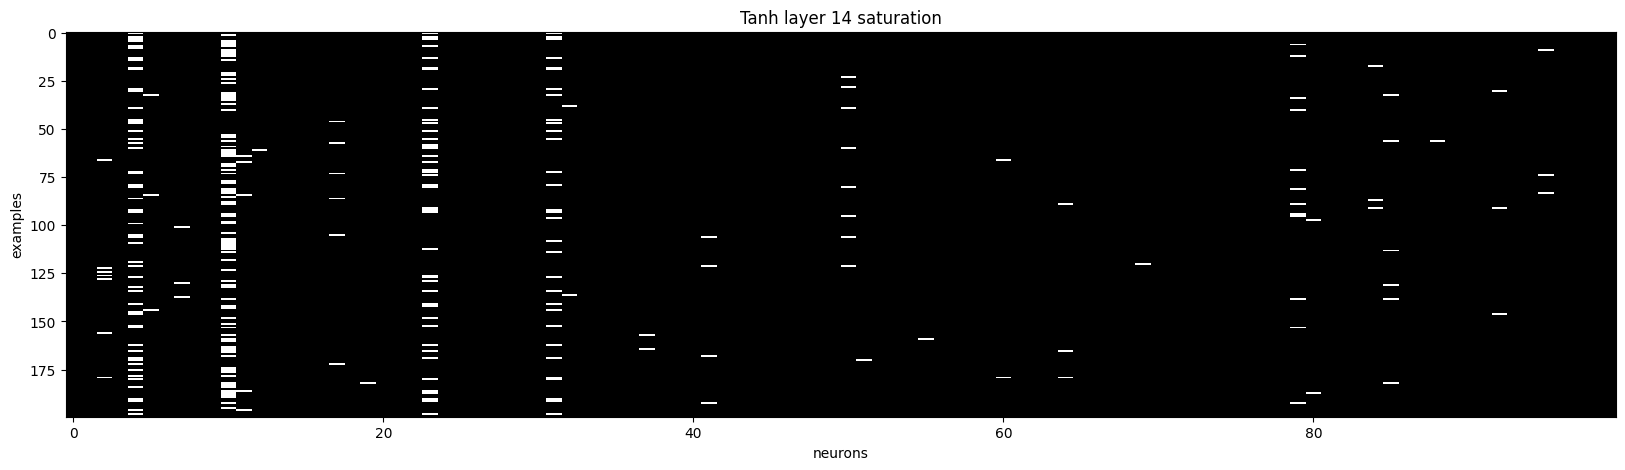

In [ ]:
# visualize saturation of Tanh activations

with torch.no_grad():

    # take a batch
    ix = torch.randint(0, Xtr.shape[0], (200,), generator=g)
    Xb = Xtr[ix]

    # embeddings
    emb = C[Xb]

    # flatten
    x = emb.view(emb.shape[0], -1)

    for i, layer in enumerate(layers):

        x = layer(x)

        if isinstance(layer, Tanh):
            t = layer.out.detach()

            print(
                f"layer {i}: shape={tuple(t.shape)}, "
                f"saturated={(t.abs() > 0.99).float().mean() * 100:.2f}%"
            )

            plt.figure(figsize=(20, 5))
            plt.imshow(
                t.abs() > 0.99,
                cmap="gray",
                interpolation="nearest",
                aspect="auto"
            )
            plt.title(f"Tanh layer {i} saturation")
            plt.xlabel("neurons")
            plt.ylabel("examples")
            plt.show()

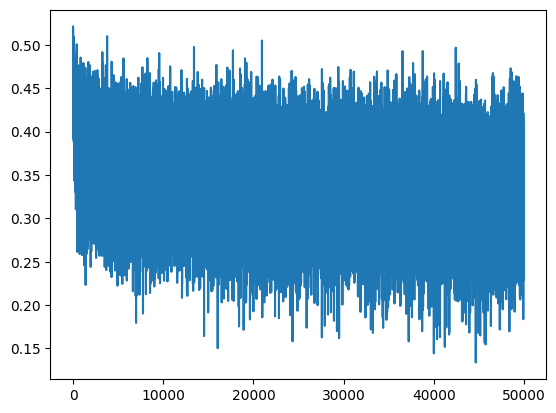

In [ ]:
plt.plot(lossi)

In [ ]:
sum(p.nelement() for p in parameters)

47497

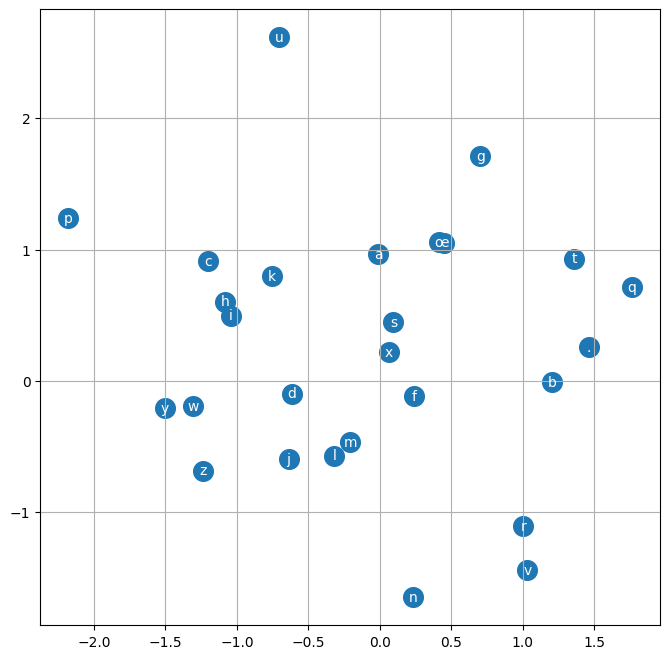

In [ ]:

# visualize dimensions 0 and 1 of the embedding matrix C for all characters
plt.figure(figsize=(8,8))
plt.scatter(C[:,0].data, C[:,1].data, s=200)
for i in range(C.shape[0]):
    plt.text(C[i,0].item(), C[i,1].item(), itos[i], ha="center", va="center", color='white')
plt.grid('minor')